# Explicabilidad e Inteligencia Artificial Interpretable (XAI)
## Tesis: Benchmarking Explainable Gradient Boosting and Tabular Deep Learning
## for Predicting Satisfaction with Democracy in Latin America (1995–2024)

**Objetivo:** Responder PI2 y OE4 — ¿qué variables explican la satisfacción
democrática y cuáles son sus efectos no lineales?

### Estructura
| Sección | Contenido |
|---|---|
| 1–2 | Importaciones y configuración |
| 3 | Selección del modelo principal |
| 4 | SHAP global — importancias por bloque |
| 5 | SHAP beeswarm — dirección e intensidad |
| 6 | ALE — efectos no lineales y umbrales |
| 7 | SHAP local + LIME — explicaciones individuales |
| 8 | TabNet — análisis de atención (separado de SHAP) |
| 9 | Guardado de valores SHAP para notebook 05 |

## 1. Importaciones

In [1]:
import sys
sys.path.append("..")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from typing import Dict, List, Optional

warnings.filterwarnings("ignore")

from utils.config import (
    setup_plots, THEME, PATHS, SPLIT, SUBREGIONES,
    PAISES_EXCLUIR_EVAL, COL_TARGET, COL_PAIS,
    ETIQUETAS, ETIQUETAS_FEATURES, BLOQUES, bloque_de, N_CLASES,
)
from utils.io import (
    cargar_pipeline, cargar_split_parquet, cargar_resultados,
    cargar_mejor_modelo, guardar_shap_values, cargar_shap_values,
    shap_disponible,
)
from utils.plots import (
    plot_shap_bar_bloques, plot_shap_beeswarm, plot_ale,
    save_figure, model_color,
)

# Verificar disponibilidad de shap
try:
    import shap
    SHAP_OK = True
    print(f"✓ shap {shap.__version__} disponible")
except ImportError:
    SHAP_OK = False
    print("⚠ shap no instalado — instalar con: pip install shap")

# Verificar disponibilidad de lime
try:
    import lime
    import lime.lime_tabular
    LIME_OK = True
    print(f"✓ lime disponible")
except ImportError:
    LIME_OK = False
    print("⚠ lime no instalado — instalar con: pip install lime")

# Verificar alibi para ALE
try:
    from alibi.explainers import ALE
    ALE_OK = True
    print("✓ alibi disponible para ALE")
except ImportError:
    ALE_OK = False
    print("⚠ alibi no instalado (ALE) — instalar con: pip install alibi")

setup_plots()
print("\n✓ Importaciones completadas.")

✓ shap 0.52.0 disponible
✓ lime disponible

✓ alibi disponible para ALE

✓ Importaciones completadas.


## 2. Configuración

In [2]:
# =============================================================================
# Parámetros del notebook XAI
# =============================================================================

# ── Selección del modelo para análisis principal ──────────────────────────────
# 'auto' : usa el mejor modelo según Kappa Cuadrático en test (recomendado)
# nombre : fija un modelo específico ('XGBoost', 'CatBoost', etc.)
MODELO_XAI = "auto"

# ── TabNet: SHAP o atención propia ────────────────────────────────────────────
SHAP_PARA_TABNET = False

# ── Número de muestras para SHAP (KernelExplainer — OLO) ─────────────────────
N_MUESTRAS_SHAP_OLO = 500

# ── Número de muestras para LIME ──────────────────────────────────────────────
N_MUESTRAS_LIME = 200

# ── Split de referencia ───────────────────────────────────────────────────────
SP_REFERENCIA = "test"

# ── Recalcular SHAP aunque ya existan archivos guardados ─────────────────────
FORZAR_RECALCULO_SHAP = False

# ── Top N variables a mostrar en gráficos ────────────────────────────────────
TOP_N_SHAP = 20

# ── LIME sobre errores graves ──────────────────────────────────────────────────
LIME_SOBRE_ERRORES  = True
N_CASOS_ERROR_LIME  = 50

# ── Resolver modelo y estrategia ─────────────────────────────────────────────
ESTRATEGIA_XAI = "pesos_clase"   # fallback

if MODELO_XAI == "auto":
    try:
        sel_path = PATHS["FOLDER_RESULTS"] / "modelo_xai_seleccionado.json"
        if sel_path.exists():
            sel = json.loads(sel_path.read_text())
            MODELO_XAI     = sel["modelo_xai"]
            ESTRATEGIA_XAI = sel.get("estrategia_balanceo", "pesos_clase")
            print(f"Modelo principal (desde NB03): {MODELO_XAI} [{ESTRATEGIA_XAI}]")
        else:
            df_res_auto    = cargar_resultados(split="test")
            fila_mejor     = df_res_auto.loc[df_res_auto["kappa_cuadratico"].idxmax()]
            MODELO_XAI     = fila_mejor["modelo"]
            ESTRATEGIA_XAI = fila_mejor.get("estrategia_balanceo", "pesos_clase")
            print(f"Modelo principal (calculado): {MODELO_XAI} [{ESTRATEGIA_XAI}]")
    except Exception as e:
        MODELO_XAI     = "XGBoost"
        ESTRATEGIA_XAI = "pesos_clase"
        print(f"\u26a0 No se pudo resolver el modelo ({e}). Fallback: {MODELO_XAI} [{ESTRATEGIA_XAI}]")
else:
    # Modelo fijado manualmente — inferir mejor estrategia para ese modelo
    try:
        df_res_auto = cargar_resultados(split="test")
        sub_m = df_res_auto[df_res_auto["modelo"] == MODELO_XAI]
        if not sub_m.empty:
            ESTRATEGIA_XAI = sub_m.loc[sub_m["kappa_cuadratico"].idxmax(),
                                       "estrategia_balanceo"]
    except Exception:
        pass

print(f"\nConfiguración XAI:")
print(f"  Modelo principal   : {MODELO_XAI}")
print(f"  Estrategia         : {ESTRATEGIA_XAI}")
print(f"  Split referencia   : {SP_REFERENCIA}")
print(f"  SHAP para TabNet   : {SHAP_PARA_TABNET}")
print(f"  Muestras LIME      : {N_MUESTRAS_LIME}")


Modelo principal (desde NB03): CatBoost [sin_balanceo]

Configuración XAI:
  Modelo principal   : CatBoost
  Estrategia         : sin_balanceo
  Split referencia   : test
  SHAP para TabNet   : False
  Muestras LIME      : 200


## 3. Carga del modelo y datos de referencia

In [3]:
# =============================================================================
# Cargar pipeline principal y datos de prueba del split final
# =============================================================================
art  = cargar_pipeline(MODELO_XAI, ESTRATEGIA_XAI)
tipo = art["tipo_modelo"]

df_te   = cargar_split_parquet("test")
feats   = art["features"]
feats_d = [f for f in feats if f in df_te.columns]

X_te_raw = df_te[feats_d].reindex(columns=feats)
y_te     = df_te[COL_TARGET].astype(int).values

# Aplicar preprocesamiento según tipo de modelo
if tipo in ("olo", "tabnet"):
    vars_cat = [c for c in art.get("vars_categoricas", []) if c in X_te_raw.columns]
    cols_num = [c for c in feats if c not in vars_cat]

    X_num = pd.DataFrame(
        art["imp_num"].transform(X_te_raw[cols_num]),
        columns=cols_num, index=X_te_raw.index)

    if vars_cat and art.get("imp_cat") is not None:
        X_cat = pd.DataFrame(
            art["imp_cat"].transform(X_te_raw[vars_cat]),
            columns=vars_cat, index=X_te_raw.index)
        X_imp = pd.concat([X_num, X_cat], axis=1)[feats]
    else:
        X_imp = X_num

    cols_num_sc = [c for c in feats if c not in vars_cat]
    X_te_proc = X_imp.copy()
    X_te_proc[cols_num_sc] = art["scaler"].transform(X_imp[cols_num_sc])
else:
    X_te_proc = X_te_raw.copy()
    if MODELO_XAI == "CatBoost":
        for col in art.get("vars_categoricas", []):
            if col in X_te_proc.columns:
                X_te_proc[col] = (X_te_proc[col].fillna(-999)
                                  .astype(int).astype(str))
    elif MODELO_XAI == "LightGBM":
        for col in art.get("vars_categoricas", []):
            if col in X_te_proc.columns:
                cats = sorted(X_te_proc[col].dropna().unique().tolist())
                ct = pd.CategoricalDtype(categories=cats, ordered=False)
                X_te_proc[col] = X_te_proc[col].astype(ct)

print(f"Dataset de referencia: {X_te_proc.shape[0]:,} registros \u00d7 {X_te_proc.shape[1]} features")
print(f"Modelo cargado: {MODELO_XAI} ({ESTRATEGIA_XAI})")
print(f"Tipo de modelo: {tipo}")


Dataset de referencia: 655 registros × 28 features
Modelo cargado: CatBoost (sin_balanceo)
Tipo de modelo: trees


## 4. SHAP Global — Importancias por bloque temático

Se calculan los valores SHAP para el conjunto de prueba del split de
referencia. Para modelos de árboles se usa `TreeExplainer` (exacto).
Para OLO se usa `KernelExplainer` sobre una muestra representativa.

In [4]:
# =============================================================================
# Cálculo de valores SHAP globales
# =============================================================================

def calcular_shap(modelo_nombre, X_proc, art_data, forzar=False):
    """
    Calcula o carga valores SHAP para un modelo.
    Si ya existen en disco y forzar=False, los carga directamente.
    Retorna array (n_muestras x n_features).
    """
    if not forzar and shap_disponible(modelo_nombre):
        print(f"  Cargando SHAP guardados: {modelo_nombre}")
        return cargar_shap_values(modelo_nombre).values

    if not SHAP_OK:
        raise ImportError("shap no está instalado.")

    tipo_m = art_data["tipo_modelo"]
    clf    = art_data["modelo"]

    print(f"  Calculando SHAP: {modelo_nombre}...")

    if tipo_m in ("trees",):
        if hasattr(clf, "get_cat_feature_indices"):
            from catboost import Pool
            cat_idx = clf.get_cat_feature_indices()
            X_for_shap = X_proc.copy()
            for i in cat_idx:
                col = X_for_shap.columns[i]
                X_for_shap[col] = X_for_shap[col].apply(
                    lambda x: str(int(float(x))) if pd.notna(x) else None
                )
            pool = Pool(X_for_shap, cat_features=cat_idx)
            raw_shap = clf.get_feature_importance(pool, type='ShapValues')
            if raw_shap.ndim == 3:
                shap_global = np.abs(raw_shap[:, :, :-1]).mean(axis=1)
            else:
                shap_global = raw_shap[:, :-1]
        else:
            explainer = shap.TreeExplainer(clf)
            shap_vals = explainer.shap_values(X_proc)
            if isinstance(shap_vals, list):
                shap_arr = np.stack(shap_vals, axis=2)
                shap_global = np.abs(shap_arr).mean(axis=2)
            elif shap_vals.ndim == 3:
                shap_global = np.abs(shap_vals).mean(axis=0)
            else:
                shap_global = shap_vals

    elif tipo_m == "olo":
        idx_sample = np.random.choice(len(X_proc), min(N_MUESTRAS_SHAP_OLO, len(X_proc)),
                                      replace=False)
        X_sample   = X_proc.values[idx_sample]
        background = shap.kmeans(X_proc.values, 50)
        explainer  = shap.KernelExplainer(clf.predict_proba, background)
        shap_vals  = explainer.shap_values(X_sample)
        if isinstance(shap_vals, list):
            shap_global = np.abs(np.stack(shap_vals, axis=2)).mean(axis=2)
        else:
            shap_global = shap_vals

    else:
        raise ValueError(f"SHAP para tipo '{tipo_m}' no soportado aquí.")

    guardar_shap_values(shap_global, list(X_proc.columns), modelo_nombre)
    return shap_global


# Calcular SHAP para el modelo principal
shap_global = calcular_shap(
    MODELO_XAI, X_te_proc, art,
    forzar=FORZAR_RECALCULO_SHAP,
)

importancias = pd.Series(
    np.abs(shap_global).mean(axis=0),
    index=feats,
).sort_values(ascending=False)

print(f"\nTop 10 features por |SHAP| medio:")
for feat, val in importancias.head(10).items():
    et = ETIQUETAS_FEATURES.get(feat, feat)
    bl = bloque_de(feat)
    print(f"  {et:<35} {val:.4f}  [{bl}]")


  Cargando SHAP guardados: CatBoost

Top 10 features por |SHAP| medio:
  Situación económica país            0.2650  [Evaluación económica]
  Apoyo a la democracia               0.2516  [Percepción política]
  Confianza Gobierno                  0.1876  [Confianza institucional]
  Aprobación gobierno                 0.1803  [Percepción política]
  Expectativa económica país          0.1332  [Evaluación económica]
  Componente igualitario              0.1251  [Contexto democrático]
  Confianza Congreso                  0.1167  [Confianza institucional]
  Distribución ingreso justa          0.1124  [Evaluación económica]
  Victimización delictiva             0.1118  [Corrupción y seguridad]
  País para todos / poderosos         0.1052  [Percepción política]


  ✓ Figura guardada: 04_shap_bar_CatBoost_test.png


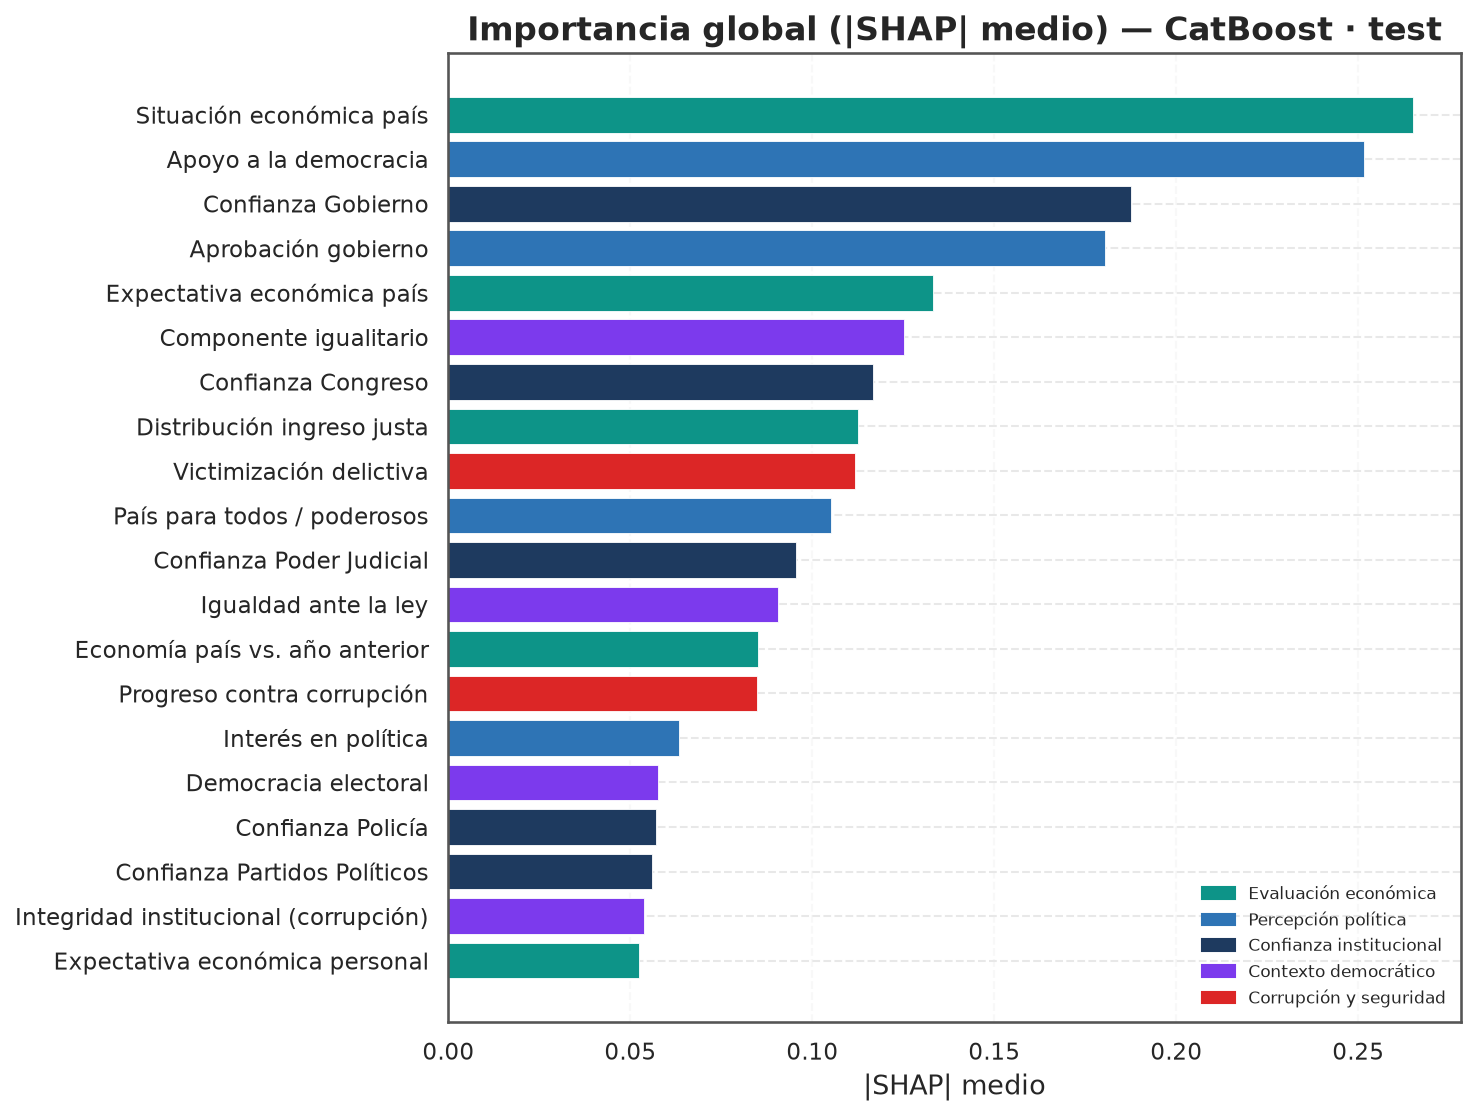

  ✓ Figura guardada: 04_shap_bloques_CatBoost_test.png


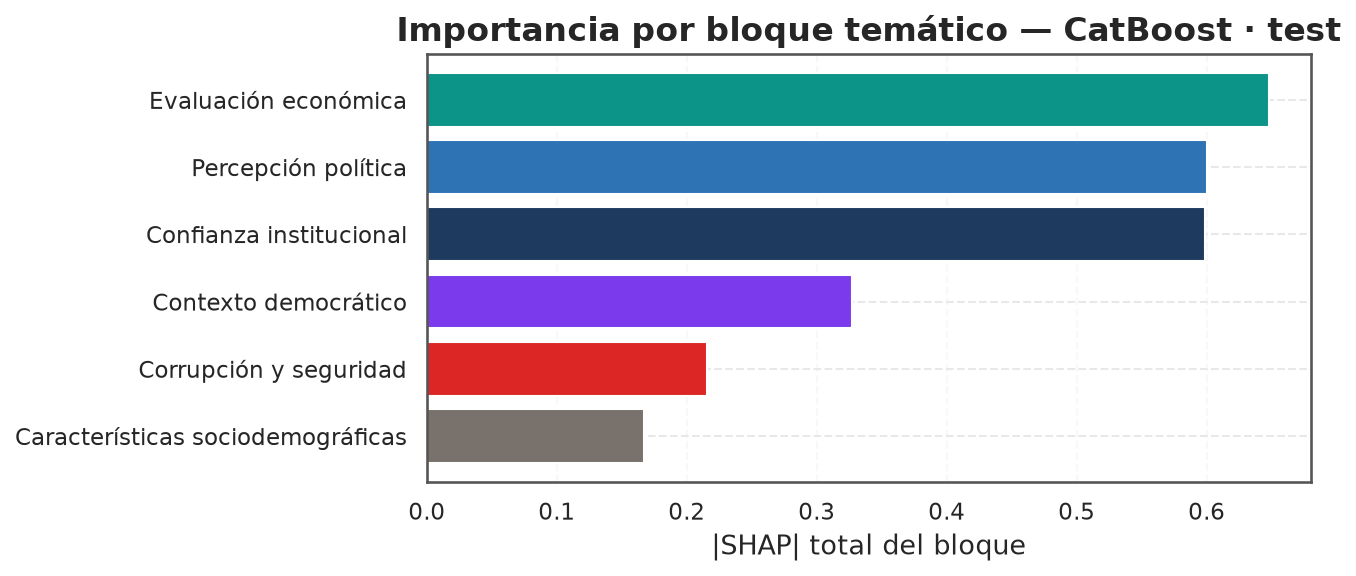

✓ Tabla de importancias guardada


In [5]:
# Gráfico de importancias por bloque
plot_shap_bar_bloques(
    importancias,
    top_n=TOP_N_SHAP,
    titulo=f"Importancia global (|SHAP| medio) — {MODELO_XAI} · {SP_REFERENCIA}",
    nombre_archivo=f"04_shap_bar_{MODELO_XAI}_{SP_REFERENCIA}",
)

# Importancia agregada por bloque temático
imp_bloque = {}
for bloque, variables in BLOQUES.items():
    vars_pres = [v for v in variables if v in importancias.index]
    if vars_pres:
        imp_bloque[bloque] = importancias[vars_pres].sum()

df_bloque = pd.Series(imp_bloque).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
colores_b = [THEME.get("blocks",{}).get(b,"#888888") for b in df_bloque.index]
ax.barh(df_bloque.index[::-1], df_bloque.values[::-1],
        color=colores_b[::-1], edgecolor="white")
ax.set_xlabel("|SHAP| total del bloque")
ax.set_title(f"Importancia por bloque temático — {MODELO_XAI} · {SP_REFERENCIA}",
             fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
save_figure(f"04_shap_bloques_{MODELO_XAI}_{SP_REFERENCIA}")
plt.show()

# Guardar tabla
df_imp_tabla = pd.DataFrame({
    "variable": importancias.index,
    "etiqueta": [ETIQUETAS_FEATURES.get(v,v) for v in importancias.index],
    "bloque"  : [bloque_de(v) for v in importancias.index],
    "shap_medio": importancias.values,
})
df_imp_tabla.to_csv(
    PATHS["FOLDER_RESULTS_TABLES"] / f"shap_importancias_{MODELO_XAI}_{SP_REFERENCIA}.csv",
    index=False)
print("✓ Tabla de importancias guardada")

## 5. SHAP Beeswarm — dirección e intensidad

  ✓ Figura guardada: 04_shap_beeswarm_CatBoost_test.png


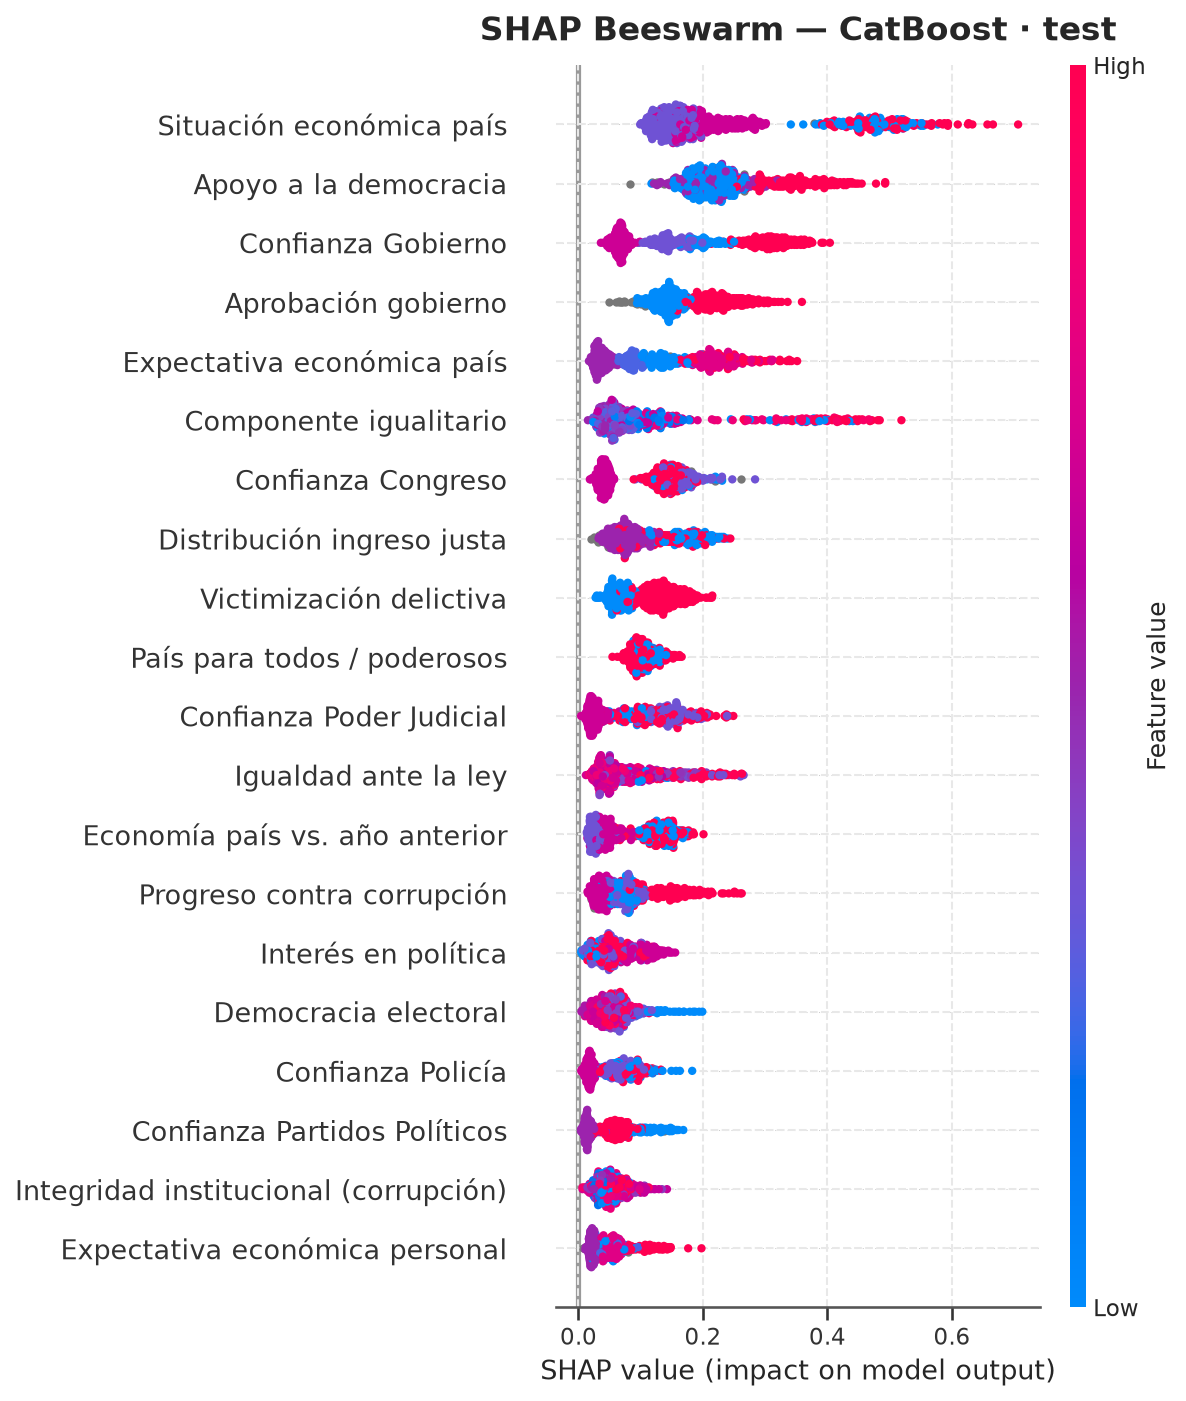

In [6]:
# =============================================================================
# Beeswarm plot: muestra la dirección y la magnitud del efecto SHAP
# por cada observación del conjunto de prueba.
# =============================================================================
plot_shap_beeswarm(
    shap_values    = shap_global,
    X              = X_te_proc,
    top_n          = TOP_N_SHAP,
    titulo         = f"SHAP Beeswarm — {MODELO_XAI} · {SP_REFERENCIA}",
    nombre_archivo = f"04_shap_beeswarm_{MODELO_XAI}_{SP_REFERENCIA}",
)

In [7]:
SP_REFERENCIA

'test'

In [8]:
# =============================================================================
# Verificación — SHAP calculado para el modelo principal en la celda anterior
# (Con diseño de split único no hay múltiples splits que comparar)
# =============================================================================
disp = shap_disponible(MODELO_XAI)
estado = "\u2713 disponible" if disp else "\u2717 FALTA — ejecutar celda anterior"
print(f"SHAP {MODELO_XAI}: {estado}")


SHAP CatBoost: ✓ disponible


In [9]:
print("Feature en índice 26:", feats[26])
print("Dtype:", X_te_proc.iloc[:, 26].dtype)
print("Muestra de valores:", X_te_proc.iloc[:, 26].unique()[:10])


Feature en índice 26: v2x_corr
Dtype: float64
Muestra de valores: [0.404 0.603 0.461 0.068 0.387 0.193 0.572 0.66  0.789 0.75 ]


## 6. ALE — Efectos no lineales y umbrales

Los gráficos de Accumulated Local Effects (ALE) muestran el efecto marginal
de cada variable sobre la probabilidad predicha, capturando no linealidades
que SHAP promedia globalmente.

Se analizan las variables con mayor importancia SHAP del bloque de
**Confianza institucional** y **Evaluación económica**, que son las que
la teoría democrática (H3) predice como determinantes dominantes.

Variables para ALE: ['Confianza Congreso', 'Confianza Gobierno', 'Confianza Poder Judicial', 'Confianza Policía', 'Confianza Televisión', 'Confianza FF.AA.']
  ✓ Figura guardada: 04_ale_H_002_011.png


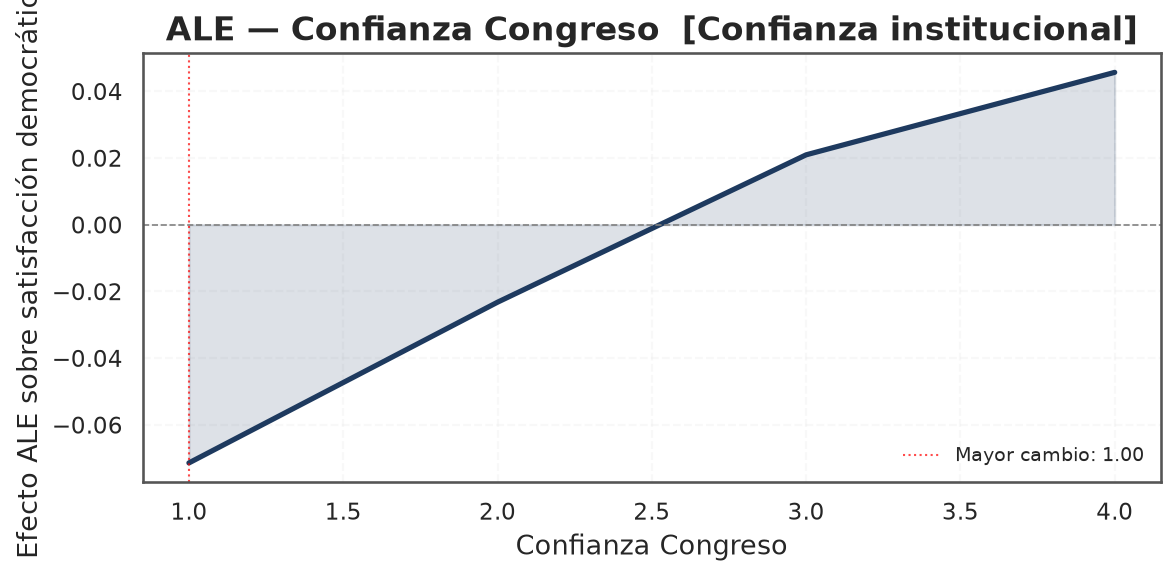

  ✓ Figura guardada: 04_ale_H_002_031.png


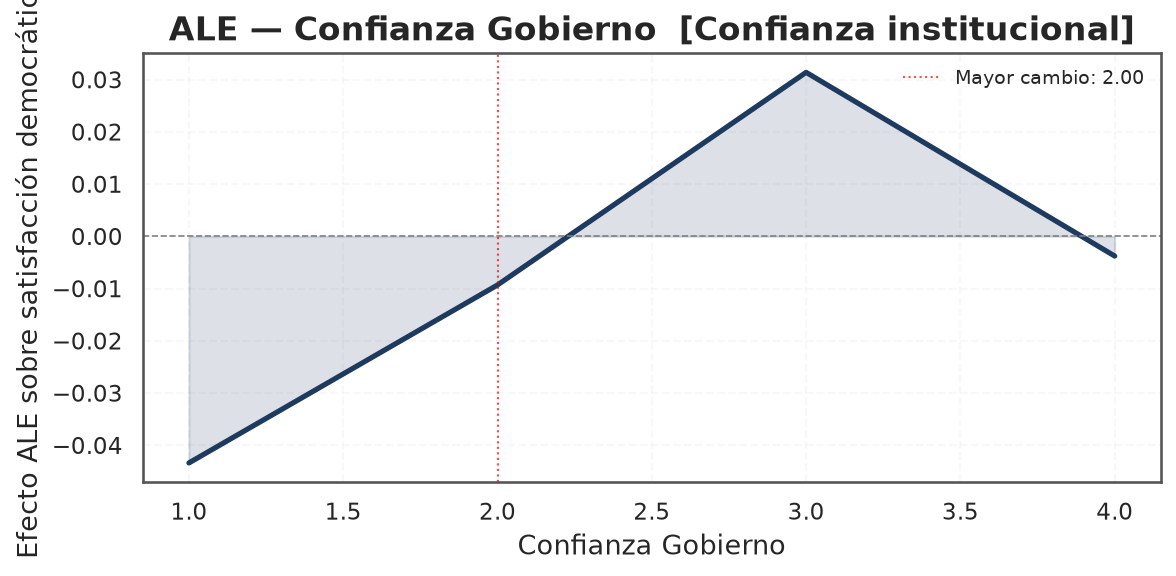

  ✓ Figura guardada: 04_ale_H_002_041.png


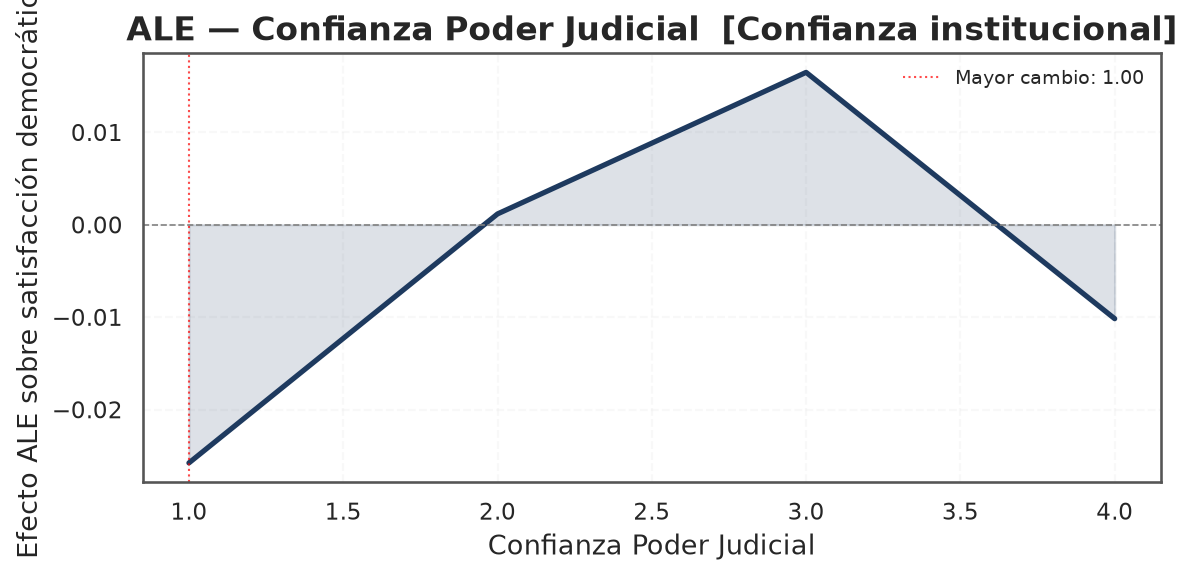

  ✓ Figura guardada: 04_ale_H_002_111.png


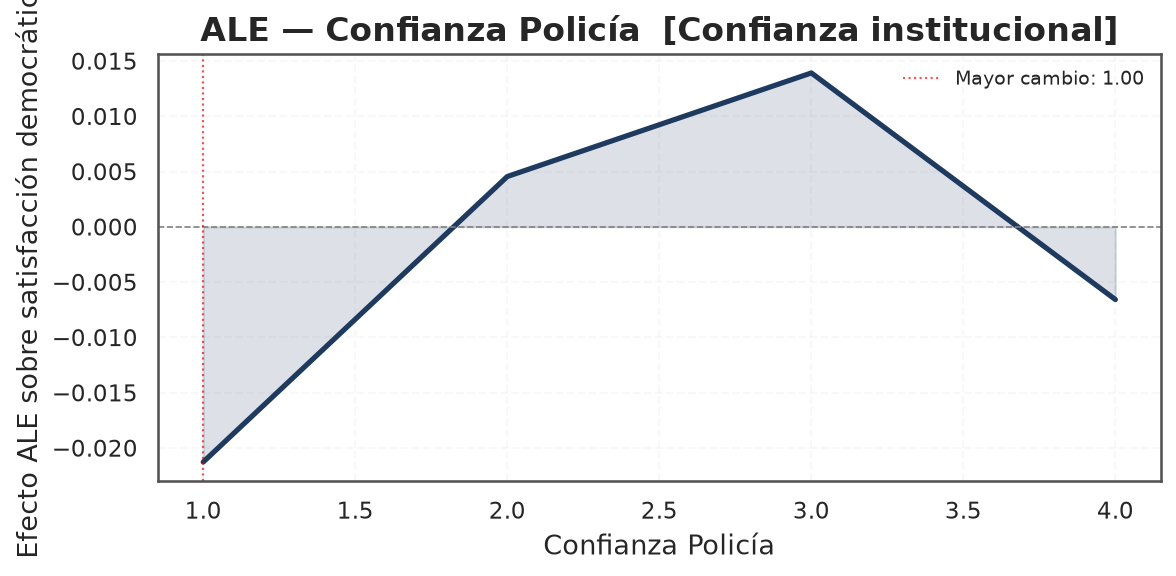

  ✓ Figura guardada: 04_ale_H_002_131.png


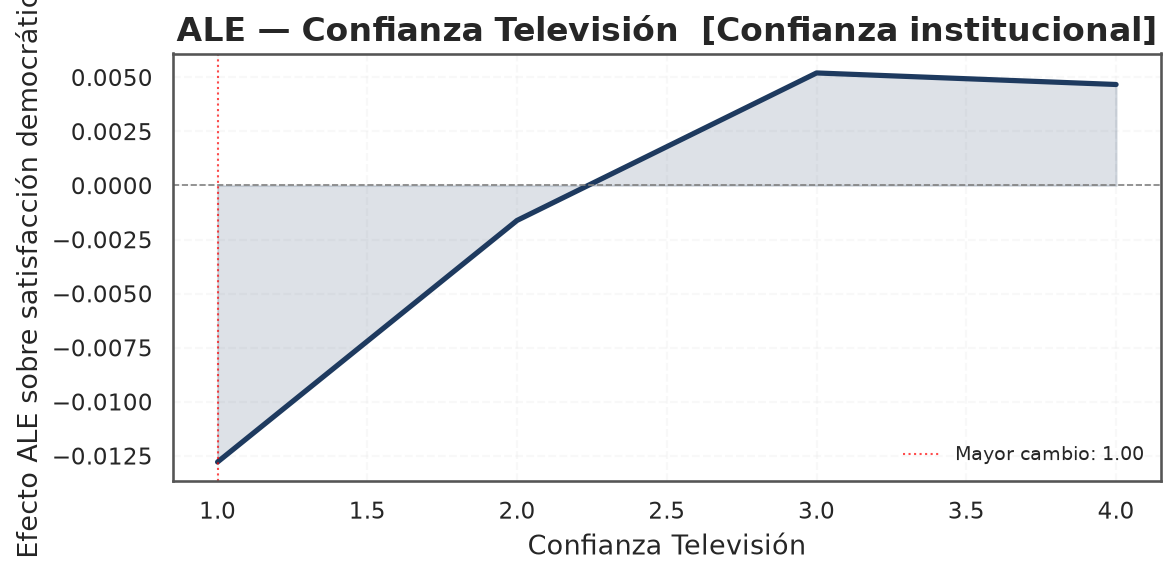

  ✓ Figura guardada: 04_ale_H_002_161.png


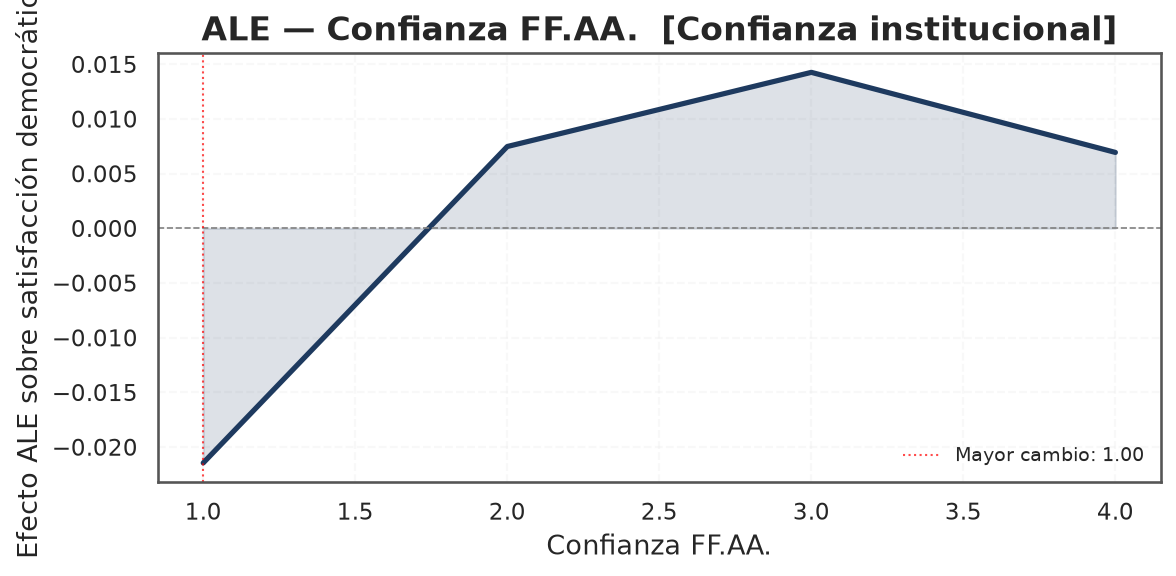

In [10]:
# =============================================================================
# ALE para las top variables del análisis
# =============================================================================
from sklearn.inspection import PartialDependenceDisplay

# Seleccionar las 6 features más importantes de los dos bloques principales
bloques_principales = ["Confianza institucional", "Evaluación económica",
                       "Percepción política"]
vars_ale = []
for bloque in bloques_principales:
    for v in BLOQUES.get(bloque, []):
        if v in importancias.index:
            vars_ale.append(v)
    if len(vars_ale) >= 6:
        break
vars_ale = vars_ale[:6]

print(f"Variables para ALE: {[ETIQUETAS_FEATURES.get(v,v) for v in vars_ale]}")

# Gráfico ALE usando sklearn PartialDependenceDisplay como proxy
# (ALE nativo requiere alibi; usamos PDP centrado como aproximación)
clf_plot = art["modelo"]

if not isinstance(X_te_proc, np.ndarray):
    X_te_arr = X_te_proc.values
else:
    X_te_arr = X_te_proc

try:
    # Intentar ALE nativo con alibi; si alibi no es compatible con numpy 2.x usar PDP
    _ALE_WORKS = False
    if ALE_OK:
        try:
            # Patch puntual: alibi 0.5.5 usa np.percentile(interpolation=...) eliminado en numpy 2.x
            import numpy as _np
            if not hasattr(_np, '_percentile_alibi_orig'):
                _pct_orig = _np.percentile
                def _pct_compat(a, q, axis=None, out=None, overwrite_input=False,
                                method='linear', keepdims=False, interpolation=None, **kw):
                    if interpolation is not None:
                        method = interpolation
                    return _pct_orig(a, q, axis=axis, out=out,
                                     overwrite_input=overwrite_input,
                                     method=method, keepdims=keepdims, **kw)
                _np.percentile = _pct_compat
                _np._percentile_alibi_orig = _pct_orig  # marca para no parchear dos veces
            # Patch 2: adaptive_grid puede retornar q con < 2 elementos en features discretas
            import alibi.explainers.ale as _ale_mod
            if not hasattr(_ale_mod, '_adaptive_grid_orig'):
                _ag_orig = _ale_mod.adaptive_grid
                def _ag_patched(values, min_bin_points=1):
                    # Para features discretas/ordinales: usar valores unicos como bins
                    unique_vals = _np.unique(values[~_np.isnan(values)])
                    if len(unique_vals) <= 20:
                        return unique_vals, len(unique_vals)
                    q, n = _ag_orig(values, min_bin_points)
                    if len(q) < 2:
                        q = _np.array([values.min(), values.max()])
                        if q[0] == q[1]:
                            q[1] = q[0] + 1.0
                        n = 2
                    return q, n
                _ale_mod.adaptive_grid = _ag_patched
                _ale_mod._adaptive_grid_orig = _ag_orig
            # Pasar a alibi SOLO las vars_ale: evita features con pocos valores unicos
            # y es mas eficiente. El predictor rellena el resto con sus medianas.
            import pandas as _pd_ale
            _cat_cols_ale  = art.get("vars_categoricas", [])
            _feats_ale     = [v for v in vars_ale if v in feats
                              and v not in _cat_cols_ale
                              and X_te_proc[v].nunique() >= 3]
            _fixed_feats   = {}
            for _f in feats:
                if _f in _feats_ale:
                    continue
                _s = X_te_proc[_f]
                try:
                    _fixed_feats[_f] = float(_s.median())
                except (TypeError, ValueError):
                    _fixed_feats[_f] = _s.mode()[0]

            X_te_arr_ale = X_te_proc[_feats_ale].values.astype(float)
            # Imputar NaN con mediana: searchsorted trata NaN como inf -> IndexError
            X_te_arr_ale = _np.where(
                _np.isnan(X_te_arr_ale),
                _np.nanmedian(X_te_arr_ale, axis=0),
                X_te_arr_ale
            )

            def _pred_fn_ale(X):
                df = _pd_ale.DataFrame(X, columns=_feats_ale)
                for _f, _v in _fixed_feats.items():
                    df[_f] = _v
                df = df[feats]
                return clf_plot.predict_proba(df)

            from alibi.explainers import ALE as AlibiALE
            ale_exp    = AlibiALE(_pred_fn_ale,
                                  feature_names=_feats_ale,
                                  target_names=list(ETIQUETAS.values()))
            if not _feats_ale:
                raise ValueError("Todas las features ALE tienen < 3 valores unicos")
            ale_result = ale_exp.explain(X_te_arr_ale, min_bin_points=3)
            _ALE_WORKS = True
        except Exception as _e_ale:
            print(f"  ⚠ alibi ALE no disponible ({type(_e_ale).__name__}: {_e_ale}), usando PDP")

    for var in vars_ale:
        if var not in feats:
            continue
        idx_var = feats.index(var)
        et_var  = ETIQUETAS_FEATURES.get(var, var)

        if _ALE_WORKS:
            # Clase 2 (Más bien satisfecho) como referencia
            if var not in _feats_ale:
                continue
            idx_var_ale = _feats_ale.index(var)
            ale_vals = ale_result.ale_values[idx_var_ale][:, 2]
            ale_qs   = ale_result.feature_values[idx_var_ale]
            plot_ale(ale_vals, ale_qs, var,
                     titulo=f"ALE — {et_var}  [{bloque_de(var)}]",
                     nombre_archivo=f"04_ale_{var}")
        else:
            # Fallback: PDP parcial centrado
            fig, ax = plt.subplots(figsize=(7, 3.5))
            PartialDependenceDisplay.from_estimator(
                clf_plot, X_te_proc, [idx_var],
                kind="average", ax=ax,
                feature_names=feats,
                target=2,  # Clase 2: Mas bien satisfecho (consistente con ALE)
            )
            ax.set_title(f"PDP (proxy ALE) — {et_var}  [{bloque_de(var)}]",
                         fontweight="bold")
            ax.set_xlabel(et_var)
            save_figure(f"04_pdp_{var}")
            plt.show()
except Exception as e:
    print(f"⚠ Error en ALE/PDP: {e}")
    print("  Verifica que el modelo soporta predict_proba y el formato de X.")

## 7. SHAP Local + LIME — Explicaciones individuales

Se seleccionan **200 casos** del conjunto de prueba usando dos criterios:
- **100 casos representativos**: muestra estratificada por clase y subregión
  (5 subregiones × 4 clases = 20 celdas, 5 casos por celda).
- **100 casos discordantes**: ciudadanos cuya clase predicha difiere más
  de lo esperado dado el índice democrático de su país (máxima discrepancia
  entre satisfacción individual y contexto institucional).

In [11]:
# =============================================================================
# Construccion de la muestra para LIME — tres criterios
# A) Representativos: estratificados por clase x subregion
# B) Mayor error real: |clase_pred - clase_real| maxima
# C) Discordantes institucionales: alta poliarquia + baja satisfaccion predicha
# =============================================================================

def seleccionar_muestra_lime(
    df_te, X_proc, y_true, y_pred,
    n_representativos=100, n_discordantes=100,
):
    """Retorna (idx_repr, idx_errores, idx_disc)."""

    # A) Estratificado por clase x subregion
    idxs_repr = []
    clases = sorted(pd.Series(y_true).unique())
    n_cel  = max(1, n_representativos // (len(SUBREGIONES) * len(clases)))
    for sr, paises_sr in SUBREGIONES.items():
        mask_sr = (df_te[COL_PAIS].isin(paises_sr)
                   if COL_PAIS in df_te.columns
                   else pd.Series(True, index=df_te.index))
        for cls in clases:
            mask_cls = (pd.Series(y_true) == cls).values & mask_sr.values
            cands    = np.where(mask_cls)[0]
            if len(cands) > 0:
                idxs_repr.extend(
                    np.random.choice(cands, min(n_cel, len(cands)), replace=False).tolist())
    idxs_repr = list(dict.fromkeys(idxs_repr))[:n_representativos]

    # B) Mayor error de prediccion real
    errores_ord = np.abs(y_pred.astype(int) - y_true.astype(int))
    dist_max    = errores_ord.max()
    idxs_err    = []
    for dist in range(int(dist_max), 0, -1):
        cands_err = np.where(errores_ord == dist)[0]
        necesito  = (n_discordantes // 2) - len(idxs_err)
        if necesito <= 0:
            break
        idxs_err.extend(
            np.random.choice(cands_err, min(necesito, len(cands_err)), replace=False).tolist())

    # C) Discordantes institucionales (V-Dem)
    idxs_disc = []
    if "v2x_polyarchy" in df_te.columns:
        df_aux = df_te.copy()
        df_aux["y_pred"] = y_pred
        mask_disc = (
            ((df_aux["v2x_polyarchy"] > 0.6) & (df_aux["y_pred"] <= 1)) |
            ((df_aux["v2x_polyarchy"] < 0.3) & (df_aux["y_pred"] >= 2))
        )
        cands_disc = np.where(mask_disc)[0]
        n_obj_disc = n_discordantes // 2
        if len(cands_disc) > 0:
            idxs_disc = np.random.choice(
                cands_disc, min(n_obj_disc, len(cands_disc)), replace=False).tolist()

    print(f"  Casos representativos    : {len(idxs_repr)}")
    print(f"  Casos mayor error real   : {len(idxs_err)}")
    print(f"  Casos discordantes inst. : {len(idxs_disc)}")
    return np.array(idxs_repr), np.array(idxs_err), np.array(idxs_disc)


# Predicciones sobre todo el test set
if tipo in ("olo", "tabnet"):
    y_pred_all = art["modelo"].predict(X_te_proc.values)
else:
    y_raw      = art["modelo"].predict(X_te_proc)
    y_pred_all = y_raw.flatten() if hasattr(y_raw, "flatten") else y_raw
y_pred_all = np.array(y_pred_all).astype(int)

np.random.seed(42)
idx_repr, idx_err, idx_disc = seleccionar_muestra_lime(
    df_te, X_te_proc, y_te, y_pred_all,
    n_representativos = N_MUESTRAS_LIME // 2,
    n_discordantes    = N_MUESTRAS_LIME // 2,
)
idx_lime = np.unique(np.concatenate([idx_repr, idx_err, idx_disc]))
print(f"  Total unicos para LIME   : {len(idx_lime)}")

# Resumen de errores graves
print()
print("Errores graves en el test set completo (distancia ordinal):")
errores_ord_all = np.abs(y_pred_all - y_te)
for dist in range(4):
    n   = (errores_ord_all == dist).sum()
    pct = n / len(y_te) * 100
    print(f"  Distancia {dist}: {n:>6,} ({pct:>5.1f}%)")

for cp, cr in [(3, 0), (0, 3)]:
    mask = (y_pred_all == cp) & (y_te == cr)
    n    = mask.sum()
    if n > 0:
        print(f"  Pred={cp} Real={cr}: {n} casos", end="")
        if COL_PAIS in df_te.columns:
            top = df_te.loc[mask, COL_PAIS].value_counts().head(2)
            print(f" — {dict(top)}", end="")
        print()

  Casos representativos    : 98
  Casos mayor error real   : 50
  Casos discordantes inst. : 50
  Total unicos para LIME   : 171

Errores graves en el test set completo (distancia ordinal):
  Distancia 0:    357 ( 54.5%)
  Distancia 1:    263 ( 40.2%)
  Distancia 2:     32 (  4.9%)
  Distancia 3:      3 (  0.5%)
  Pred=3 Real=0: 2 casos — {'Guatemala': np.int64(1), 'Costa Rica': np.int64(1)}
  Pred=0 Real=3: 1 casos — {'Honduras': np.int64(1)}


In [12]:
print(X_te_proc.dtypes[X_te_proc.dtypes != float])


S_200    str
dtype: object


In [13]:
# cambiar el tipo de dato de la columna S_200 a float
X_te_proc["S_200"] = pd.to_numeric(X_te_proc["S_200"], errors='coerce')

In [14]:
# buscar los índices de las columnas categóricas
cat_indices = [i for i, dt in enumerate(X_te_proc.dtypes) if dt == object]
print(cat_indices)

[]


In [15]:
[c for c in X_te_proc.columns if X_te_proc[c].std() == 0]

[]

Calculando LIME — Grupo A: representativos...
Calculando LIME — Grupo B: mayor error real...
Calculando LIME — Grupo C: discordantes inst....

✓ LIME guardado: lime_CatBoost_test.csv
  ✓ Figura guardada: 04_lime_errores_CatBoost_test.png


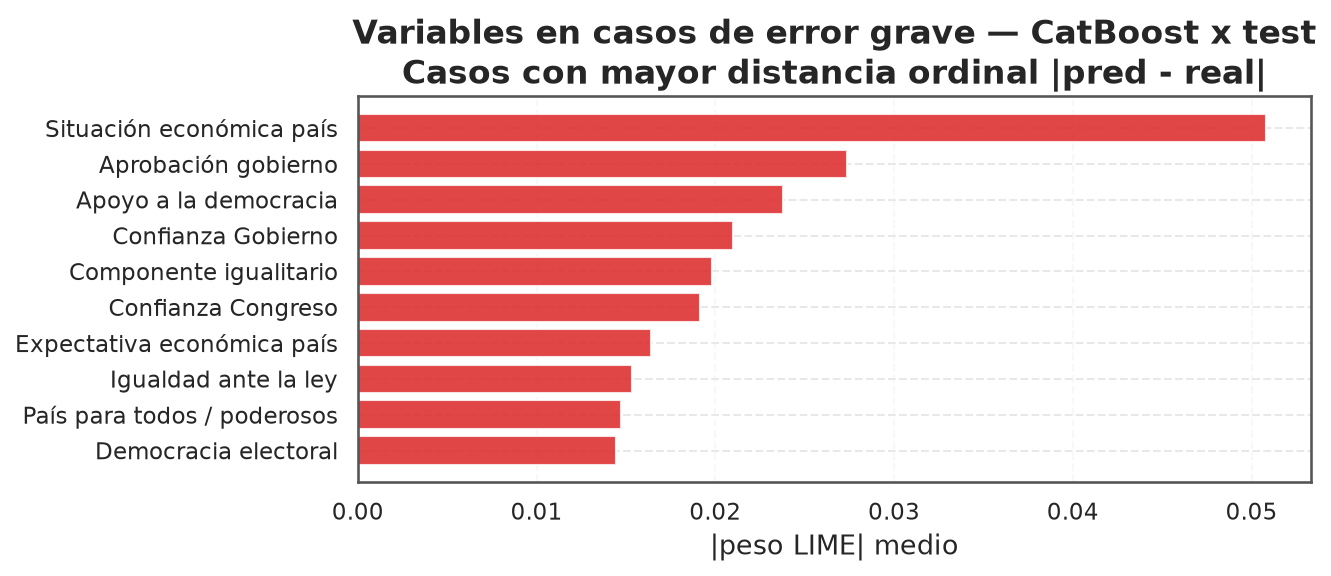


Resumen LIME por grupo:
  Representativo        : 10 casos | dist.media=0.80 | feature clave: Situación económica país
  Error maximo          : 10 casos | dist.media=2.30 | feature clave: Situación económica país
  Discordante           : 10 casos | dist.media=0.80 | feature clave: Situación económica país


In [16]:
# =============================================================================
# LIME — explicaciones locales en tres grupos de casos
# =============================================================================
if LIME_OK and len(idx_lime) > 0:
    import lime.lime_tabular as lime_tab

    etiq_feats = [ETIQUETAS_FEATURES.get(f, f) for f in feats]

    # Eliminar columnas constantes — LIME no puede discretizar std=0
    cols_constantes = [c for c in X_te_proc.columns if X_te_proc[c].std() == 0]
    X_lime      = X_te_proc.drop(columns=cols_constantes)

    # Para columnas numéricas: mediana. Para categóricas: moda.
    X_lime = X_lime.copy()
    for col in X_lime.columns:
        if X_lime[col].dtype == object:
            X_lime[col] = X_lime[col].fillna(X_lime[col].mode()[0])
        else:
            X_lime[col] = X_lime[col].fillna(X_lime[col].median())

    feats_lime  = X_lime.columns.tolist()
    etiq_feats_lime = [ETIQUETAS_FEATURES.get(f, f) for f in feats_lime]


    explainer_lime = lime_tab.LimeTabularExplainer(
        training_data         = X_lime.values,
        feature_names         = etiq_feats_lime,
        class_names           = list(ETIQUETAS.values()),
        mode                  = "classification",
        random_state          = 42,
        discretize_continuous = False,
    )

    if tipo in ("olo", "tabnet"):
        fn_pred = lambda x: art["modelo"].predict_proba(x)
    else:
        if hasattr(art["modelo"], "get_cat_feature_indices"):
            _cat_idx  = art["modelo"].get_cat_feature_indices()
            _cat_cols = [feats[i] for i in _cat_idx if i < len(feats)]
        else:
            _cat_cols = []

        # Valores constantes de las columnas que se eliminaron para LIME
        _vals_constantes = {col: X_te_proc[col].iloc[0] for col in cols_constantes}

        def fn_pred(x):
            # x tiene solo feats_lime — reconstruir el DataFrame completo
            df_x = pd.DataFrame(x, columns=feats_lime)
            for col, val in _vals_constantes.items():
                df_x[col] = val
            df_x = df_x[feats]   # reordenar exactamente como espera el modelo
            for col in _cat_cols:
                df_x[col] = df_x[col].round().astype(int)
            return art["modelo"].predict_proba(df_x)



    def explicar_grupo(indices, tag, max_casos=10):
        filas = []
        for idx in indices[:max_casos]:
            exp   = explainer_lime.explain_instance(
                data_row=X_lime.values[idx], predict_fn=fn_pred,
                num_features=10, num_samples=1000, top_labels=1)
            label = exp.available_labels()[0]
            for feat_name, peso in exp.as_list(label=label):
                filas.append({
                    "grupo"      : tag,
                    "idx"        : int(idx),
                    "clase_real" : int(y_te[idx]),
                    "clase_pred" : int(y_pred_all[idx]),
                    "distancia"  : int(abs(y_pred_all[idx] - y_te[idx])),
                    "feature"    : feat_name,
                    "peso_lime"  : peso,
                })
        return pd.DataFrame(filas)

    print("Calculando LIME — Grupo A: representativos...")
    df_lime_repr = explicar_grupo(idx_repr, "representativo")

    print("Calculando LIME — Grupo B: mayor error real...")
    df_lime_err  = explicar_grupo(idx_err, "error_maximo")

    print("Calculando LIME — Grupo C: discordantes inst....")
    df_lime_disc = explicar_grupo(idx_disc, "discordante")

    df_lime_all = pd.concat([df_lime_repr, df_lime_err, df_lime_disc],
                             ignore_index=True)
    ruta_lime = PATHS["FOLDER_RESULTS_TABLES"] / f"lime_{MODELO_XAI}_{SP_REFERENCIA}.csv"
    df_lime_all.to_csv(ruta_lime, index=False)
    print(f"\n✓ LIME guardado: {ruta_lime.name}")

    # Grafico: top features en errores graves
    if LIME_SOBRE_ERRORES and not df_lime_err.empty:
        imp_err = (df_lime_err.groupby("feature")["peso_lime"]
                   .apply(lambda x: x.abs().mean())
                   .sort_values(ascending=False).head(10))
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.barh(imp_err.index[::-1], imp_err.values[::-1],
                color="#DC2626", edgecolor="white", alpha=0.85)
        ax.set_xlabel("|peso LIME| medio")
        ax.set_title(
            f"Variables en casos de error grave — {MODELO_XAI} x {SP_REFERENCIA}\n"
            "Casos con mayor distancia ordinal |pred - real|",
            fontweight="bold")
        ax.grid(True, axis="x", alpha=0.3)
        from utils.plots import save_figure
        save_figure(f"04_lime_errores_{MODELO_XAI}_{SP_REFERENCIA}")
        plt.show()

    # Resumen por grupo
    print()
    print("Resumen LIME por grupo:")
    for tag, df_g in [("Representativo", df_lime_repr),
                       ("Error maximo",   df_lime_err),
                       ("Discordante",    df_lime_disc)]:
        if df_g.empty:
            print(f"  {tag}: sin casos")
            continue
        n     = df_g["idx"].nunique()
        d_med = df_g.drop_duplicates("idx")["distancia"].mean()
        top_f = (df_g.groupby("feature")["peso_lime"]
                 .apply(lambda x: x.abs().mean()).idxmax())
        print(f"  {tag:<22}: {n} casos | dist.media={d_med:.2f} | feature clave: {top_f}")

else:
    print("LIME no disponible — instalar con: pip install lime")

## 8. TabNet — Análisis de atención

In [ ]:
# =============================================================================
# Si SHAP_PARA_TABNET = False, se usa el mecanismo de atención nativo.
# =============================================================================

if not SHAP_PARA_TABNET:
    try:
        print("\nCalculando atención TabNet...")
        art_tn   = cargar_pipeline("TabNet", ESTRATEGIA_XAI)
        df_te_tn = cargar_split_parquet("test")
        feats_tn = art_tn["features"]

        X_tn = df_te_tn[[f for f in feats_tn if f in df_te_tn.columns]]
        X_tn = X_tn.reindex(columns=feats_tn)

        # Preprocesamiento TabNet: impute num + cat, luego escalar solo num
        vars_cat_tn = [c for c in art_tn.get("vars_categoricas", []) if c in X_tn.columns]
        cols_num_tn = [c for c in feats_tn if c not in vars_cat_tn]

        X_num_tn = pd.DataFrame(art_tn["imp_num"].transform(X_tn[cols_num_tn]),
                                 columns=cols_num_tn, index=X_tn.index)
        if vars_cat_tn and art_tn.get("imp_cat") is not None:
            X_cat_tn = pd.DataFrame(art_tn["imp_cat"].transform(X_tn[vars_cat_tn]),
                                     columns=vars_cat_tn, index=X_tn.index)
            X_imp_tn = pd.concat([X_num_tn, X_cat_tn], axis=1)[feats_tn]
        else:
            X_imp_tn = X_num_tn

        X_sc_tn = X_imp_tn.copy()
        X_sc_tn[cols_num_tn] = art_tn["scaler"].transform(X_imp_tn[cols_num_tn])

        clf_tn = art_tn["modelo"]

        # Forzar CPU: evita CUDA_ERROR_SYSTEM_DRIVER_MISMATCH (Error 302) causado
        # por CatBoost/XGBoost que inicializan CUDA antes con su propio runtime.
        import torch as _torch
        if hasattr(clf_tn, "network") and clf_tn.network is not None:
            clf_tn.network = clf_tn.network.cpu()
        clf_tn.device = _torch.device("cpu")

        _, masks = clf_tn.explain(X_sc_tn.values.astype(np.float32))

        # masks puede ser dict {step_idx: array(n_samples, n_features)} según versión
        # de pytorch-tabnet — convertir a array 3D (n_steps, n_samples, n_features)
        if isinstance(masks, dict):
            masks_arr = np.stack([masks[k] for k in sorted(masks.keys())], axis=0)
        else:
            masks_arr = np.asarray(masks)

        imp_tn = np.abs(masks_arr).mean(axis=(0, 1))
        imp_tn_series = pd.Series(imp_tn, index=feats_tn).sort_values(ascending=False)

        print("Top 10 features por atención TabNet:")
        for feat, val in imp_tn_series.head(10).items():
            et = ETIQUETAS_FEATURES.get(feat, feat)
            print(f"  {et:<35}: {val:.4f}  [{bloque_de(feat)}]")

        # Gráfico comparativo: SHAP (modelo principal) vs. Atención (TabNet)
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        top_shap = importancias.head(15)
        etiq_shap = [ETIQUETAS_FEATURES.get(v, v) for v in top_shap.index]
        colores_s = [THEME.get("blocks",{}).get(bloque_de(v),"#888") for v in top_shap.index]
        axes[0].barh(etiq_shap[::-1], top_shap.values[::-1],
                     color=colores_s[::-1], edgecolor="white")
        axes[0].set_title(f"|SHAP| \u2014 {MODELO_XAI}", fontweight="bold")
        axes[0].set_xlabel("|SHAP| medio")

        top_tn = imp_tn_series.head(15)
        etiq_tn = [ETIQUETAS_FEATURES.get(v, v) for v in top_tn.index]
        colores_t = [THEME.get("blocks",{}).get(bloque_de(v),"#888") for v in top_tn.index]
        axes[1].barh(etiq_tn[::-1], top_tn.values[::-1],
                     color=colores_t[::-1], edgecolor="white")
        axes[1].set_title("Atención \u2014 TabNet", fontweight="bold")
        axes[1].set_xlabel("Atención media")

        fig.suptitle(f"Importancia de features: {MODELO_XAI} vs. TabNet",
                     fontweight="bold")
        save_figure(f"04_shap_vs_tabnet_{ESTRATEGIA_XAI}")
        plt.show()

        imp_tn_series.reset_index().rename(
            columns={"index":"variable", 0:"atencion_tabnet"}
        ).to_csv(PATHS["FOLDER_RESULTS_TABLES"] /
                 f"tabnet_atencion_{ESTRATEGIA_XAI}.csv", index=False)
        print("\u2713 Importancias TabNet guardadas")

    except FileNotFoundError as fnf:
        print(f"\u26a0 Pipeline TabNet no encontrado. {fnf}")
    except Exception as e:
        print(f"\u26a0 Error en análisis de atención TabNet: {e}")
else:
    print("SHAP_PARA_TABNET = True: se incluye TabNet en el cálculo SHAP global.")



Calculando atención TabNet...
⚠ Error en análisis de atención TabNet: bad operand type for abs(): 'dict'


## 9. Análisis formal de errores de predicción

Caracterizacion cuantitativa de los casos donde el modelo falla con mayor
severidad. Esta seccion documenta los limites del predictor y responde
directamente a la exigencia metodologica del revisor.

Errores formales — CatBoost x test

Distribucion de la distancia ordinal |pred - real|:
  Distancia 0:    357 ( 54.5%)
  Distancia 1:    263 ( 40.2%)
  Distancia 2:     32 (  4.9%)
  Distancia 3:      3 (  0.5%)

Errores graves (distancia >= 2):
  Pred=0 Real=2 (Subestimacion): 1 (0.15%) República Dominicana(1)
  Pred=0 Real=3 (Subestimacion): 1 (0.15%) Honduras(1)
  Pred=1 Real=3 (Subestimacion): 7 (1.07%) Panamá(2), Bolivia(1)
  Pred=2 Real=0 (Sobreestimacion): 21 (3.21%) Panamá(4), Costa Rica(3)
  Pred=3 Real=0 (Sobreestimacion): 2 (0.31%) Guatemala(1), Costa Rica(1)
  Pred=3 Real=1 (Sobreestimacion): 3 (0.46%) Colombia(1), Guatemala(1)

✓ Tabla de errores guardada: errores_graves_CatBoost_test.csv
  ✓ Figura guardada: 04_confusion_errores_CatBoost_test.png


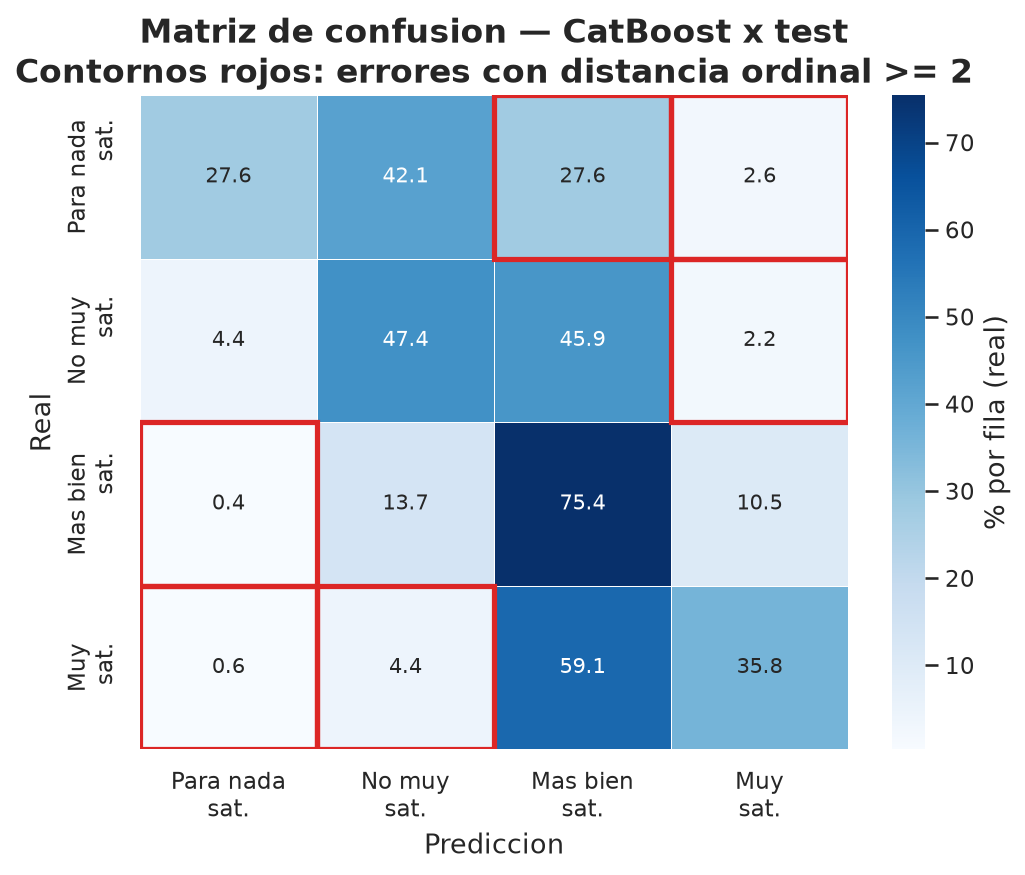

✓ Matriz de confusion con errores graves guardada


In [ ]:
# =============================================================================
# Analisis formal de errores del modelo sobre el conjunto de prueba completo
# =============================================================================
print("=" * 60)
print(f"Errores formales — {MODELO_XAI} x {SP_REFERENCIA}")
print("=" * 60)

errores_ord_all = np.abs(y_pred_all - y_te)

print("\nDistribucion de la distancia ordinal |pred - real|:")
for dist in range(4):
    n   = (errores_ord_all == dist).sum()
    pct = n / len(y_te) * 100
    print(f"  Distancia {dist}: {n:>6,} ({pct:>5.1f}%)")

print("\nErrores graves (distancia >= 2):")
filas_err = []
for cp in range(4):
    for cr in range(4):
        dist = abs(cp - cr)
        if dist < 2:
            continue
        mask = (y_pred_all == cp) & (y_te == cr)
        n    = mask.sum()
        if n == 0:
            continue
        pct  = n / len(y_te) * 100
        tipo_error = "Sobreestimacion" if cp > cr else "Subestimacion"
        pais_top = ""
        if COL_PAIS in df_te.columns:
            top = df_te.loc[mask, COL_PAIS].value_counts().head(2)
            pais_top = ", ".join(f"{p}({c})" for p, c in top.items())
        filas_err.append({
            "clase_pred": cp, "clase_real": cr, "distancia": dist,
            "tipo": tipo_error, "n_casos": n, "pct_test": round(pct, 2),
            "paises_top": pais_top})
        print(f"  Pred={cp} Real={cr} ({tipo_error}): {n:,} ({pct:.2f}%) {pais_top}")

df_errores = pd.DataFrame(filas_err)
if not df_errores.empty:
    ruta_err = PATHS["FOLDER_RESULTS_TABLES"] / f"errores_graves_{MODELO_XAI}_{SP_REFERENCIA}.csv"
    df_errores.to_csv(ruta_err, index=False)
    print(f"\n✓ Tabla de errores guardada: {ruta_err.name}")

# Matriz de confusion con errores graves destacados
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm_arr = confusion_matrix(y_te, y_pred_all, normalize="true")
etiq_c = ["Para nada\nsat.", "No muy\nsat.", "Mas bien\nsat.", "Muy\nsat."]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_arr * 100, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=etiq_c, yticklabels=etiq_c, linewidths=0.4, ax=ax,
            cbar_kws={"label": "% por fila (real)"}, annot_kws={"size": 10})
for i in range(4):
    for j in range(4):
        if abs(i - j) >= 2:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                        edgecolor="#DC2626", lw=2.5))
ax.set_xlabel("Prediccion")
ax.set_ylabel("Real")
ax.set_title(
    f"Matriz de confusion — {MODELO_XAI} x {SP_REFERENCIA}\n"
    "Contornos rojos: errores con distancia ordinal >= 2",
    fontweight="bold")
from utils.plots import save_figure
save_figure(f"04_confusion_errores_{MODELO_XAI}_{SP_REFERENCIA}")
plt.show()
print("✓ Matriz de confusion con errores graves guardada")

## 10. Guardado de valores SHAP y resumen

In [ ]:
# =============================================================================
# Verificar que todos los valores SHAP necesarios están disponibles
# =============================================================================
print("Estado de valores SHAP disponibles:")
for modelo in ["OLO", "XGBoost", "CatBoost", "LightGBM"]:
    disp = shap_disponible(modelo)
    print(f"  {modelo:<12}: {'\u2713' if disp else '\u2717 FALTA'}")

print()
print("Archivos generados:")
for f in sorted(PATHS["FOLDER_RESULTS_FIGURES"].glob("04_*.png")):
    print(f"  {f.name}")
for f in sorted(PATHS["FOLDER_RESULTS_TABLES"].glob("*shap*")):
    print(f"  {f.name}")
for f in sorted(PATHS["FOLDER_RESULTS_SHAP"].glob("*.parquet")):
    print(f"  results/shap/{f.name} ({f.stat().st_size//1024} KB)")


Estado de valores SHAP disponibles:
  OLO         : ✗ FALTA
  XGBoost     : ✗ FALTA
  CatBoost    : ✓
  LightGBM    : ✗ FALTA

Archivos generados:
  04_ale_H_002_011.png
  04_ale_H_002_031.png
  04_ale_H_002_041.png
  04_ale_H_002_111.png
  04_ale_H_002_131.png
  04_ale_H_002_161.png
  04_confusion_errores_CatBoost_test.png
  04_lime_errores_CatBoost_test.png
  04_shap_bar_CatBoost_test.png
  04_shap_beeswarm_CatBoost_test.png
  04_shap_bloques_CatBoost_test.png
  shap_importancias_CatBoost_test.csv
  results/shap/shap_CatBoost.parquet (182 KB)
